In [8]:
import  os
num_cores = "1"
os.environ["OPENBLAS_NUM_THREADS"] = num_cores
os.environ["OMP_NUM_THREADS"] = num_cores
os.environ["MKL_NUM_THREADS"] = num_cores

In [2]:
# Importing modules
import time
import math
import numpy as np
import scipy.sparse as ssp
import scipy.sparse.linalg
from scipy.sparse import diags,eye
#%matplotlib notebook
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.io import loadmat
import timeit
import scipy.io
from qutip import *
import zeropi as zp
from tqdm import tqdm

In [3]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE, labelsize=MEDIUM_SIZE)     # fontsize of the axes
plt.rc(['xtick', 'ytick' ], labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [4]:
# Device parameters
EL        = 0.38 # GHz
EJ        = 6.0   # GHz
EC_phi    = 1.14 # GHz
EC_theta  = 0.092 # GHz

In [7]:
phiext = 0
n_eval = 5
ngate_1 =  np.linspace(-0.5, .5, 21)
E_ng = []
eval0 = []
for ngate in tqdm(ngate_1):
    H = zp.Hamiltonian_2D(phiext, ngate, EC_phi, EC_theta, EJ, EL)
    evals, _ = ssp.linalg.eigsh(H, k=n_eval, which='SA', tol=1.e-10)
    # print(evals)
    eval0.append(evals)
    evals        = evals - evals[0] # Define the 0 energy with respect to the lowest lying state.
    E_ng.append(evals)        
E_ng = np.array(E_ng)
eval0 = np.array(eval0)

100%|██████████| 21/21 [00:06<00:00,  3.11it/s]


In [10]:
eval0[0]

array([-5.73619289, -3.2246811 , -2.30814572, -2.28354379, -0.88485317])

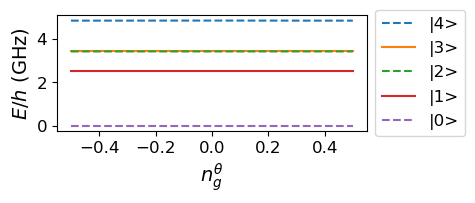

In [89]:
label_vec = ['--', '-', '--', '-', '--']

fig, ax = plt.subplots(figsize=(4,1.5))
for n1 in reversed(np.arange(0,5)):
    plt.plot(ngate_1, E_ng[:,n1], linestyle=label_vec[n1], label='|'+str(n1)+'>', alpha=1.)
    
ax.set_xlabel(r'$n_g^{\theta}$')
# ax.set_ylim([0, 12])
ax.set_ylabel(r'$E/h\ (\mathrm{GHz})$')
# ax.set_title(r'Energy levels of 2D $0-\pi$ qubits')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.savefig('eval_5_levels_101.png', dpi=300, bbox_inches='tight')

In [70]:
ngate = -0.5
phiext_1 =  np.linspace(-0.5, .5, 101)
energies = []
for phiext in tqdm(phiext_1):
    H = zp.Hamiltonian_2D(phiext, ngate, EC_phi, EC_theta, EJ, EL)
    evals, _ = ssp.linalg.eigsh(H, k=n_eval, which='SA', tol=1.e-10)
    evals        = np.sort(evals)
    evals        = evals - evals[0] # Define the 0 energy with respect to the lowest lying state.
    energies.append(evals)        
energies = np.array(energies)

100%|██████████| 101/101 [01:01<00:00,  1.65it/s]


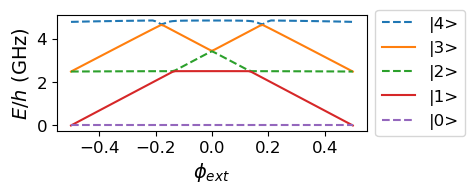

In [77]:
fig, ax = plt.subplots(figsize=(4,1.5))
for n1 in reversed(np.arange(0,5)):
    plt.plot(phiext_1, energies[:,n1], linestyle=label_vec[n1], label='|'+str(n1)+'>', alpha=1.)
    
ax.set_xlabel(r'$\phi_{ext}$')
ax.set_ylabel(r'$E/h\ (\mathrm{GHz})$')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('eval_vs_phiext.png', dpi=300, bbox_inches='tight')

# Plot double well potential

In [12]:
eval0[0]

array([-5.73619289, -3.2246811 , -2.30814572, -2.28354379, -0.88485317])

In [22]:
def potential(args, Ej=6., El=0.38, phiext=0.):
    theta, phi = args
    return -2*Ej*np.cos(theta)*np.cos(phi - np.pi*phiext) + El*phi**2

phi_0_vec = np.linspace(-np.pi, np.pi, num=101)
phi_pi_vec = np.linspace(-2*np.pi, 2*np.pi, num=101)
V_0 = [potential(args=(0, phi0)) for phi0 in phi_0_vec]
V_pi = [potential(args=(np.pi, phi0)) for phi0 in phi_pi_vec]

(-6.911503837897545,
 6.911503837897545,
 -13.950089934482792,
 28.951888624138615)

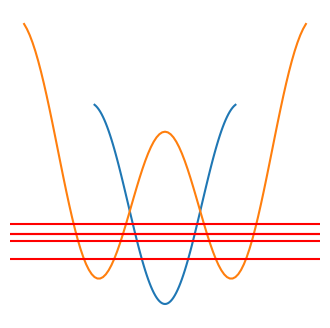

In [23]:
fig, ax = plt.subplots(figsize=(4,4))
plt.plot(phi_0_vec, V_0)
plt.plot(phi_pi_vec, V_pi)
for num in eval0[0]:
    plt.axhline(y=num, color='r', linestyle='-')
plt.axis('off')
# plt.xlabel('$\phi$')
# ax.set_ylabel(r'$E/h\ (\mathrm{GHz})$')


In [26]:
from scipy.optimize import fsolve


# Initial guess for the root
initial_guess = (1., 1.)

# Solve the equation numerically
solution = fsolve(potential, initial_guess)

print("Solution:", solution)

TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'potential'.Shape should be (2,) but it is (1,).

In [27]:
from scipy.optimize import fsolve
import numpy as np

def equations(vars):
    x, y = vars
    eq1 = x**2 + y**2 - 25
    eq2 = x - y
    return [eq1, eq2]

# Initial guess for the solution
initial_guess = [1.0, 1.0]

# Solve the system of equations numerically
solution = fsolve(equations, initial_guess)

print("Solution:", solution)


Solution: [3.53553391 3.53553391]


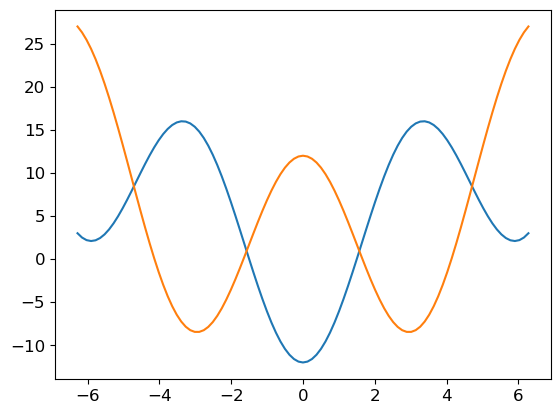

In [86]:
def potential(theta, phi, Ej=6., El=0.38, phiext=0.):
    return -2*Ej*np.cos(theta)*np.cos(phi - np.pi*phiext) + El*phi**2

phi_0_vec = np.linspace(-2*np.pi, 2*np.pi, num=101)
phi_pi_vec = np.linspace(-2*np.pi, 2*np.pi, num=101)
V_0 = [potential(theta=0, phi=phi0) for phi0 in phi_0_vec]
V_pi = [potential(theta=np.pi, phi=phi0) for phi0 in phi_pi_vec]

plt.plot(phi_0_vec, V_0)
plt.plot(phi_pi_vec, V_pi)

# Other codes

In [127]:
# Create the zeropi object in phase (phi) and charge (theta) basis.
zeropi2 = nsq.Zeropi(                      
                    E_J          = 6.0,                        # Josephson energy [GHz]
                    E_C_theta    = 0.09,                       # charging energy for the theta mode [GHz]
                    E_C_phi      = 1.14,                       # charging energy for the phi mode [GHz]
                    E_L          = 0.38,                       # inductive energy [GHz]
                    n_gate       = -0.5,                         # gate voltage
                    n_gate_ls    = np.linspace(-0.5, 0.5, 21), # gate voltages to sweep          
                    phi_ext      = -0.25,                         # external flux
                    phi_ext_ls   = np.linspace(-0.5, 0.5, 21), # external flux to sweep
                    phase_limits = [6*np.pi, np.pi],           # boundaries of phase space [phi, theta]
                    keig         = 20,                         # number of states to calculate
                    dims         = [3, 5],                 # number of points in phase space [phi, theta]
                    beta         = [0.27, 0.007],              # coupling constant for a coupled transmon-resonator case
                    f_resonator  = 7.                          # frequency of the coupled resonator [GHz]
                    )

H, V, system_operators = zeropi2.hamiltonian()
m1=H_zeropi_2D(-0.25, -0.5, EC_phi, EC_theta, EJ, EL)#phiext=0, ngate=0
eval01, _=ssp.linalg.eigsh(m1, k=10, which='SA', tol=1.e-10)
eval02, _=ssp.linalg.eigsh(H, k=10, which='SA', tol=1.e-10)
print(eval01-eval02)

[-1.30534009e-05 -5.49925280e-07  2.68218970e-05 -5.01650205e-06
 -6.43698505e-06 -3.39874009e-06 -9.58855196e-07  6.48213123e-06
 -2.15955621e-05 -1.96710175e-05]


In [4]:
import numsimqubits.qubits as nsq
import numsimqubits.qubits.build_operators as bop
# Create the zeropi object in phase (phi) and charge (theta) basis.
zeropi2 = nsq.Zeropi(                      
                    E_J          = 6.0,                        # Josephson energy [GHz]
                    E_C_theta    = 0.09,                       # charging energy for the theta mode [GHz]
                    E_C_phi      = 1.14,                       # charging energy for the phi mode [GHz]
                    E_L          = 0.38,                       # inductive energy [GHz]
                    n_gate       = -0.5,                         # gate voltage
                    n_gate_ls    = np.linspace(-0.5, 0.5, 21), # gate voltages to sweep          
                    phi_ext      = -0.5,                         # external flux
                    phi_ext_ls   = np.linspace(-0.5, 0.5, 21), # external flux to sweep
                    phase_limits = [6*np.pi, np.pi],           # boundaries of phase space [phi, theta]
                    keig         = 20,                         # number of states to calculate
                    dims         = [3, 5],                 # number of points in phase space [phi, theta]
                    beta         = [0.27, 0.007],              # coupling constant for a coupled transmon-resonator case
                    f_resonator  = 7.                          # frequency of the coupled resonator [GHz]
                    )
H, V, system_operators, ss = zeropi2.hamiltonian()
# Load operators for phi in phase basis.
ops_phi = bop.operators_phase_basis(compact_variable=False, Nx=3, Dx=6*np.pi) 

# Load operators for theta in charge basis.
ops_theta = bop.operators_charge_basis(Nx=5)

In [5]:
ss

3